# RF-Behavior demo
This notebook shows how to
1. download a part of the dataset,
2. load one trial and draw each modality.

It follows the [OctoNet demo](https://github.com/Myrmecos/OctoNet_demo)
(`load_recording`, `iter_segments`, `show_keyframe`)

## 1. Data download
RF-Behavior follows the OctoNet file convention (`<node>_<modality>_<scene>_<user>_<activity>_<trial>_<timestamp>.zip`)

1. Request access on the [dataset page](https://huggingface.co/datasets/Si-Z/RF-Behavior) (gated, academic use) and
   log in once: `hf auth login`.
2. Write a `config.json` with the users, modalities, and activities, for example:

```json
{"node_id": null, "modality_id": ["radar", "lora", "rfid", "mocap", "imu"],
 "scene_id": ["1"], "user_id": ["1", "3"], "activity_id": ["A01", "E01"], "trial_id": ["1"]}
```

   This is `config_example.json`: the trials used below (walking of user 1, focus of user 3), 13 zips.

   (`scene_id` 1 = laboratory; `activity_id` = class code M01-M21, A01-A10, E01-E06; `node_id` r, 5, 13, 14, x.)
3. `python streaming.py --config_path config_example.json --local_dir downloaded_rfbehavior` (in this folder)

**No unzip step**: the loader reads the zips. The download also brings `scripts/` (loader, readers); this notebook uses them from there.

## 2. Data loading and visualization
`load_recording` loads every modality of one trial. A trial is one recorded gesture (C1), activity (C2), or
affective behavior (C3) of one participant; it is already cut, so `trial_id` (the repetition number) picks it.
`node_id` keeps one radar (0 to 12); the other modalities have one node each and stay (LoRa 5, RFID 13, infrared
cameras 14, IMUs x). `iter_segments` yields `(start, end, clip)`; C3 trials are about 2 minutes long, so
`segment_s` splits them into windows.

`show_keyframe(clip, view)` draws one modality: the radar point cloud and the skeleton at the key frame (the middle
of the clip), the others over the whole clip.

In [2]:
import os
from rfb_demo import list_recordings, load_recording, iter_segments, show_keyframe, VIEWS

DATASET_ROOT = os.environ.get("RFB_ROOT", "downloaded_rfbehavior")   # the download folder next to this notebook
list_recordings(DATASET_ROOT, campaign="C2", user_id=1).head(10)

C:\Users\zuos1\OneDrive - Aalto University\Research_related\DATA\RF-Behavior\other\rf_behavior_sync_pipeline\downloaded_rfbehavior\scripts\loader\rfbehavior_loader.py:94: DtypeWarning: Columns (16,29,31,33) have mixed types. Specify dtype option on import or set low_memory=False.
  tables.append(pd.read_csv(path, dtype={"class": str, "repetition": str, "timestamp": str}))


,campaign,user_id,class,class_name,trial_id,timestamp,modalities,on_disk
0,C2,1,A01,walking,1,20250717144742,radar lora rfid mocap,radar lora rfid mocap


In [3]:
recording = load_recording(DATASET_ROOT, user_id=1, activity="walking", trial_id=1)
print(f"user {recording['user_id']}, {recording['campaign']} {recording['activity']} {recording['activity_name']}, "
      f"trial {recording['trial_id']}, time stamp {recording['timestamp']}")
print(f"{len(recording['segments'])} segment(s), missing: {recording['missing'] or 'none'}")
for name in ("radar", "lora", "rfid", "mocap", "imu"):
    if name in recording:
        print(f"  {name}: nodes {sorted(recording[name], key=lambda k: (isinstance(k, str), k))}")

start, end, clip = next(iter_segments(recording))
print(f"key frame from the first segment: {start} -> {end}")

user 1, C2 A01 walking, trial 1, time stamp 20250717144742
1 segment(s), missing: none
  radar: nodes [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
  lora: nodes [5]
  rfid: nodes [13]
  mocap: nodes [14]
key frame from the first segment: 2025-07-17 14:47:42.247000+03:00 -> 2025-07-17 14:47:59.877000+03:00


C:\Users\zuos1\OneDrive - Aalto University\Research_related\DATA\RF-Behavior\other\rf_behavior_sync_pipeline\downloaded_rfbehavior\scripts\loader\rfbehavior_loader.py:94: DtypeWarning: Columns (16,29,31,33) have mixed types. Specify dtype option on import or set low_memory=False.
  tables.append(pd.read_csv(path, dtype={"class": str, "repetition": str, "timestamp": str}))


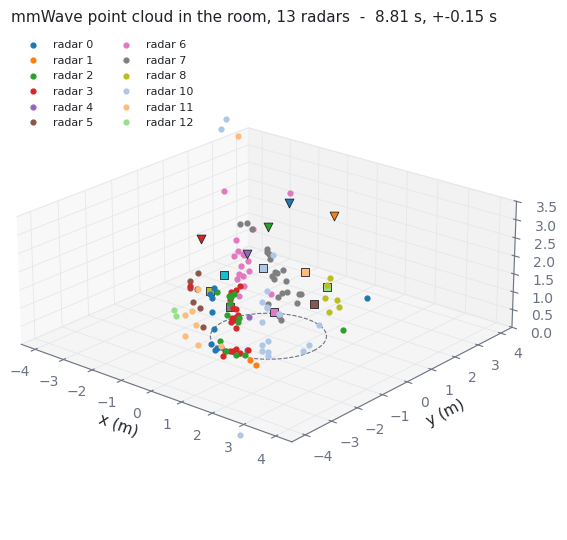

In [4]:
show_keyframe(clip, "radar", "mmWave point cloud in the room, 13 radars")

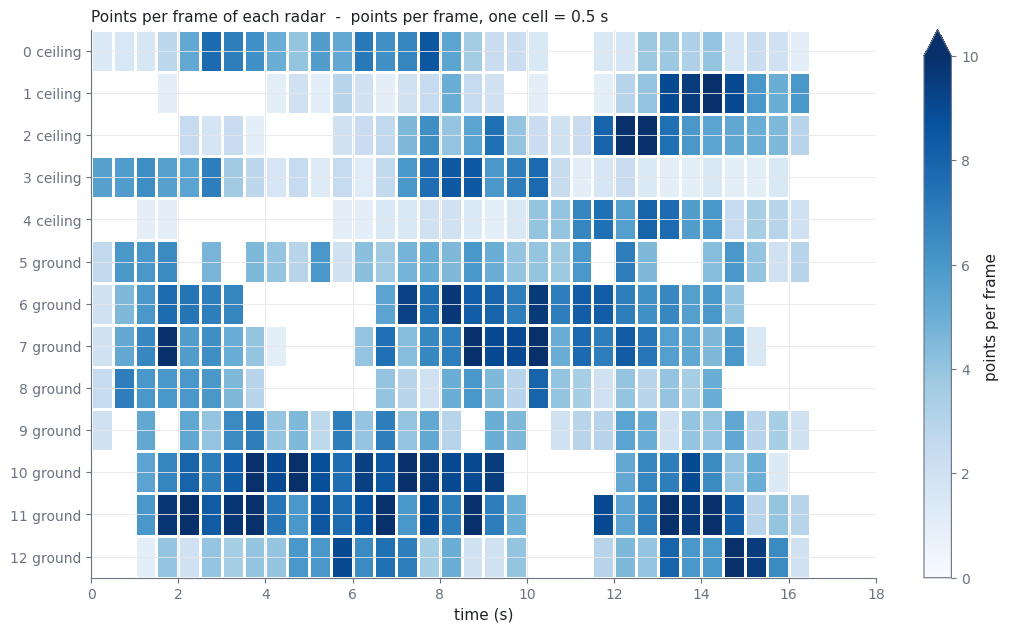

In [5]:
show_keyframe(clip, "radar_time", "Points per frame of each radar")

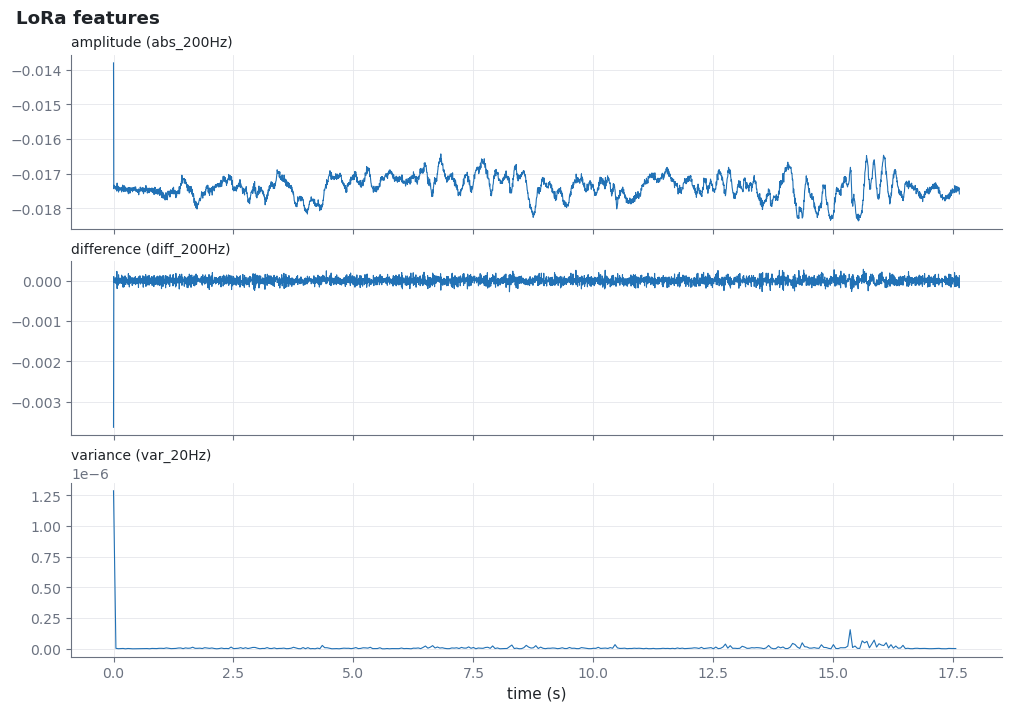

In [6]:
show_keyframe(clip, "lora", "LoRa features")

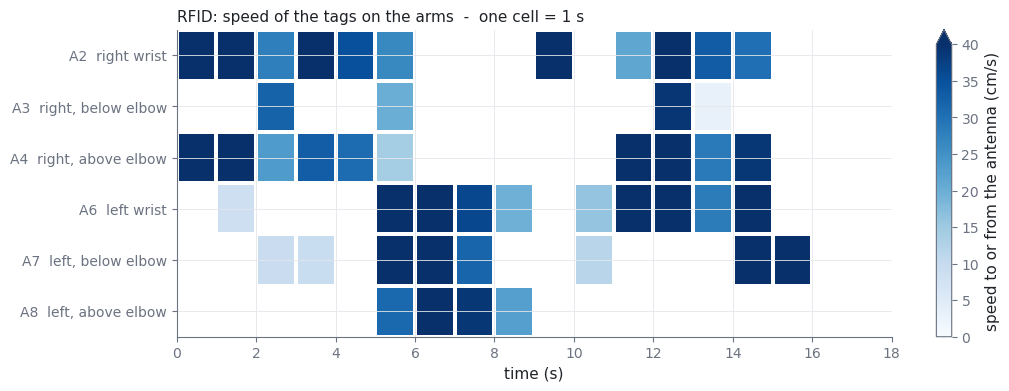

In [7]:
show_keyframe(clip, "rfid", "RFID: speed of the tags on the arms")

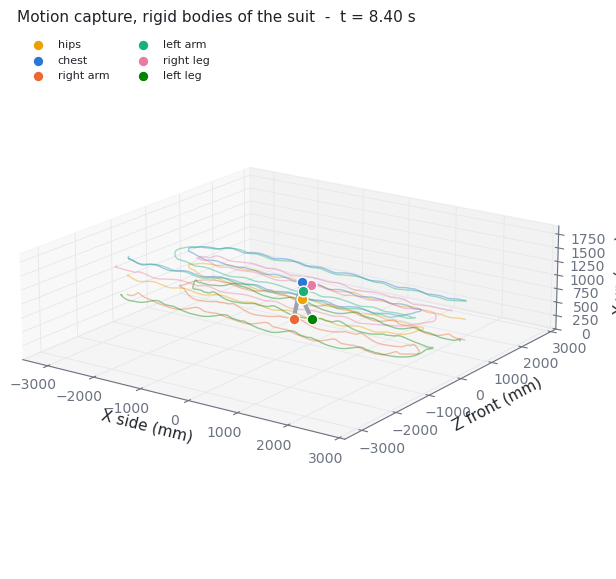

In [8]:
show_keyframe(clip, "mocap", "Motion capture, rigid bodies of the suit")

### A long trial in windows
A C3 trial (affective behavior) lasts about 2 minutes and has the IMUs. `segment_s=10` gives 10 s windows;
`node_id=5` keeps radar 5 only.

C:\Users\zuos1\OneDrive - Aalto University\Research_related\DATA\RF-Behavior\other\rf_behavior_sync_pipeline\downloaded_rfbehavior\scripts\loader\rfbehavior_loader.py:94: DtypeWarning: Columns (16,29,31,33) have mixed types. Specify dtype option on import or set low_memory=False.
  tables.append(pd.read_csv(path, dtype={"class": str, "repetition": str, "timestamp": str}))


E01 focus: 13 windows of 10 s
window 2: 2025-07-20 18:07:53.869000+03:00 -> 2025-07-20 18:08:03.869000+03:00


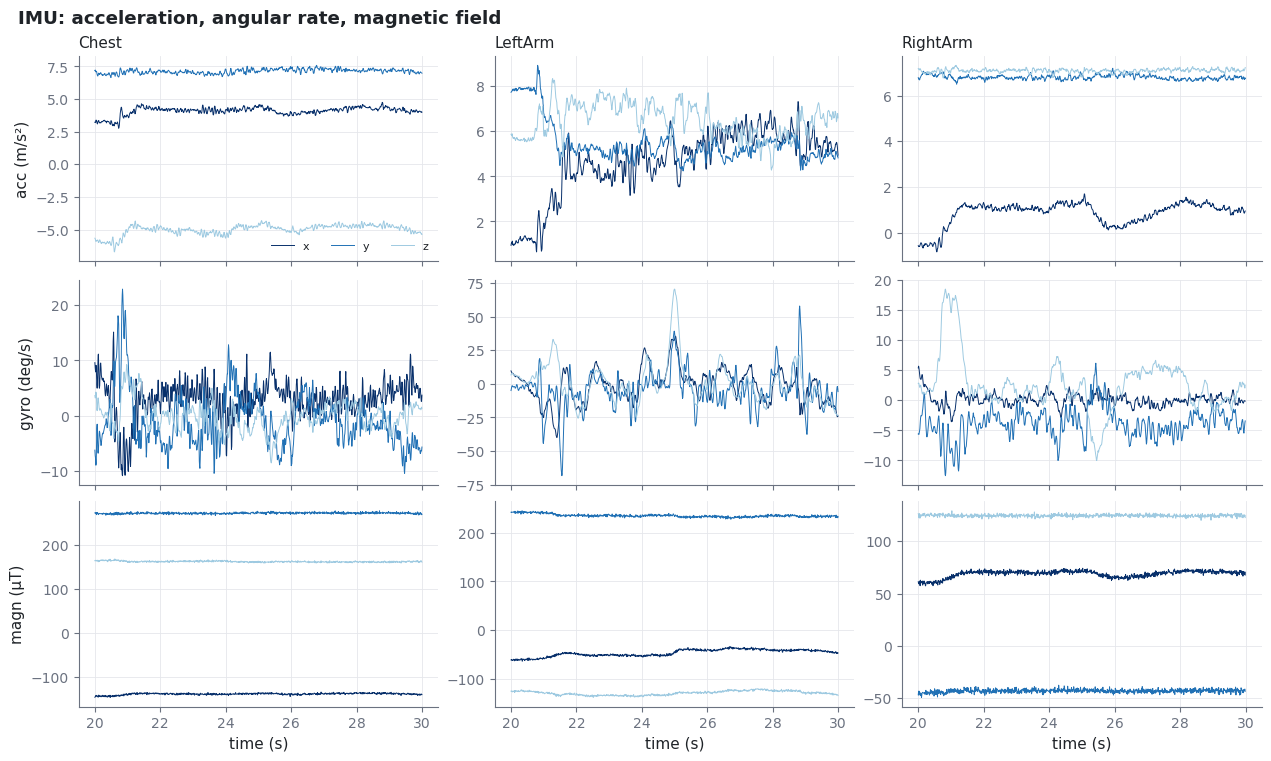

In [9]:
recording = load_recording(DATASET_ROOT, user_id=3, activity="E01", trial_id=1, node_id=5, segment_s=10)
print(f"{recording['activity']} {recording['activity_name']}: {len(recording['segments'])} windows of 10 s")
segments = list(iter_segments(recording))
start, end, clip = segments[2]
print(f"window 2: {start} -> {end}")
show_keyframe(clip, "imu", "IMU: acceleration, angular rate, magnetic field")

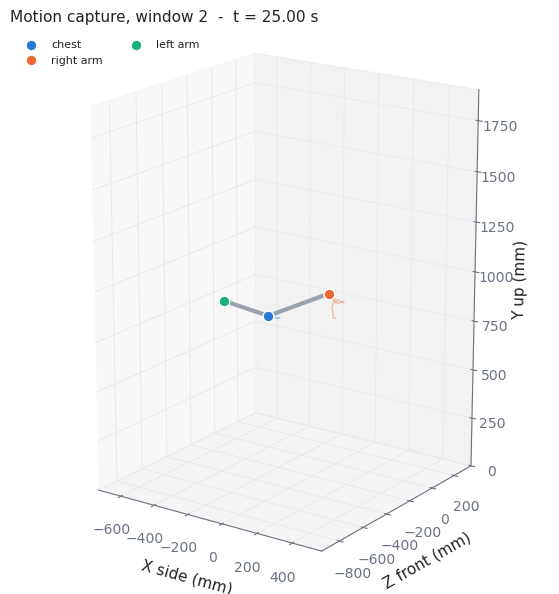

In [10]:
show_keyframe(clip, "mocap", "Motion capture, window 2")

### Modalities of OctoNet that RF-Behavior does not have
A note will be given instead of a figure.

In [11]:
for view in ("depth", "wifi", "acoustic", "polar"):
    show_keyframe(clip, view)
print("Views of RF-Behavior:", ", ".join(VIEWS))

Note: 'depth' is not in RF-Behavior: no depth camera (RF-Behavior has infrared motion capture instead of cameras). Views: radar, radar_time, lora, rfid, mocap, imu.
Note: 'wifi' is not in RF-Behavior: no WiFi CSI (the LoRa link at 865.5 MHz is the narrowband RF modality). Views: radar, radar_time, lora, rfid, mocap, imu.
Note: 'acoustic' is not in RF-Behavior: no microphone. Views: radar, radar_time, lora, rfid, mocap, imu.
Note: 'polar' is not in RF-Behavior: no heart-rate sensor. Views: radar, radar_time, lora, rfid, mocap, imu.
Views of RF-Behavior: radar, radar_time, lora, rfid, mocap, imu
